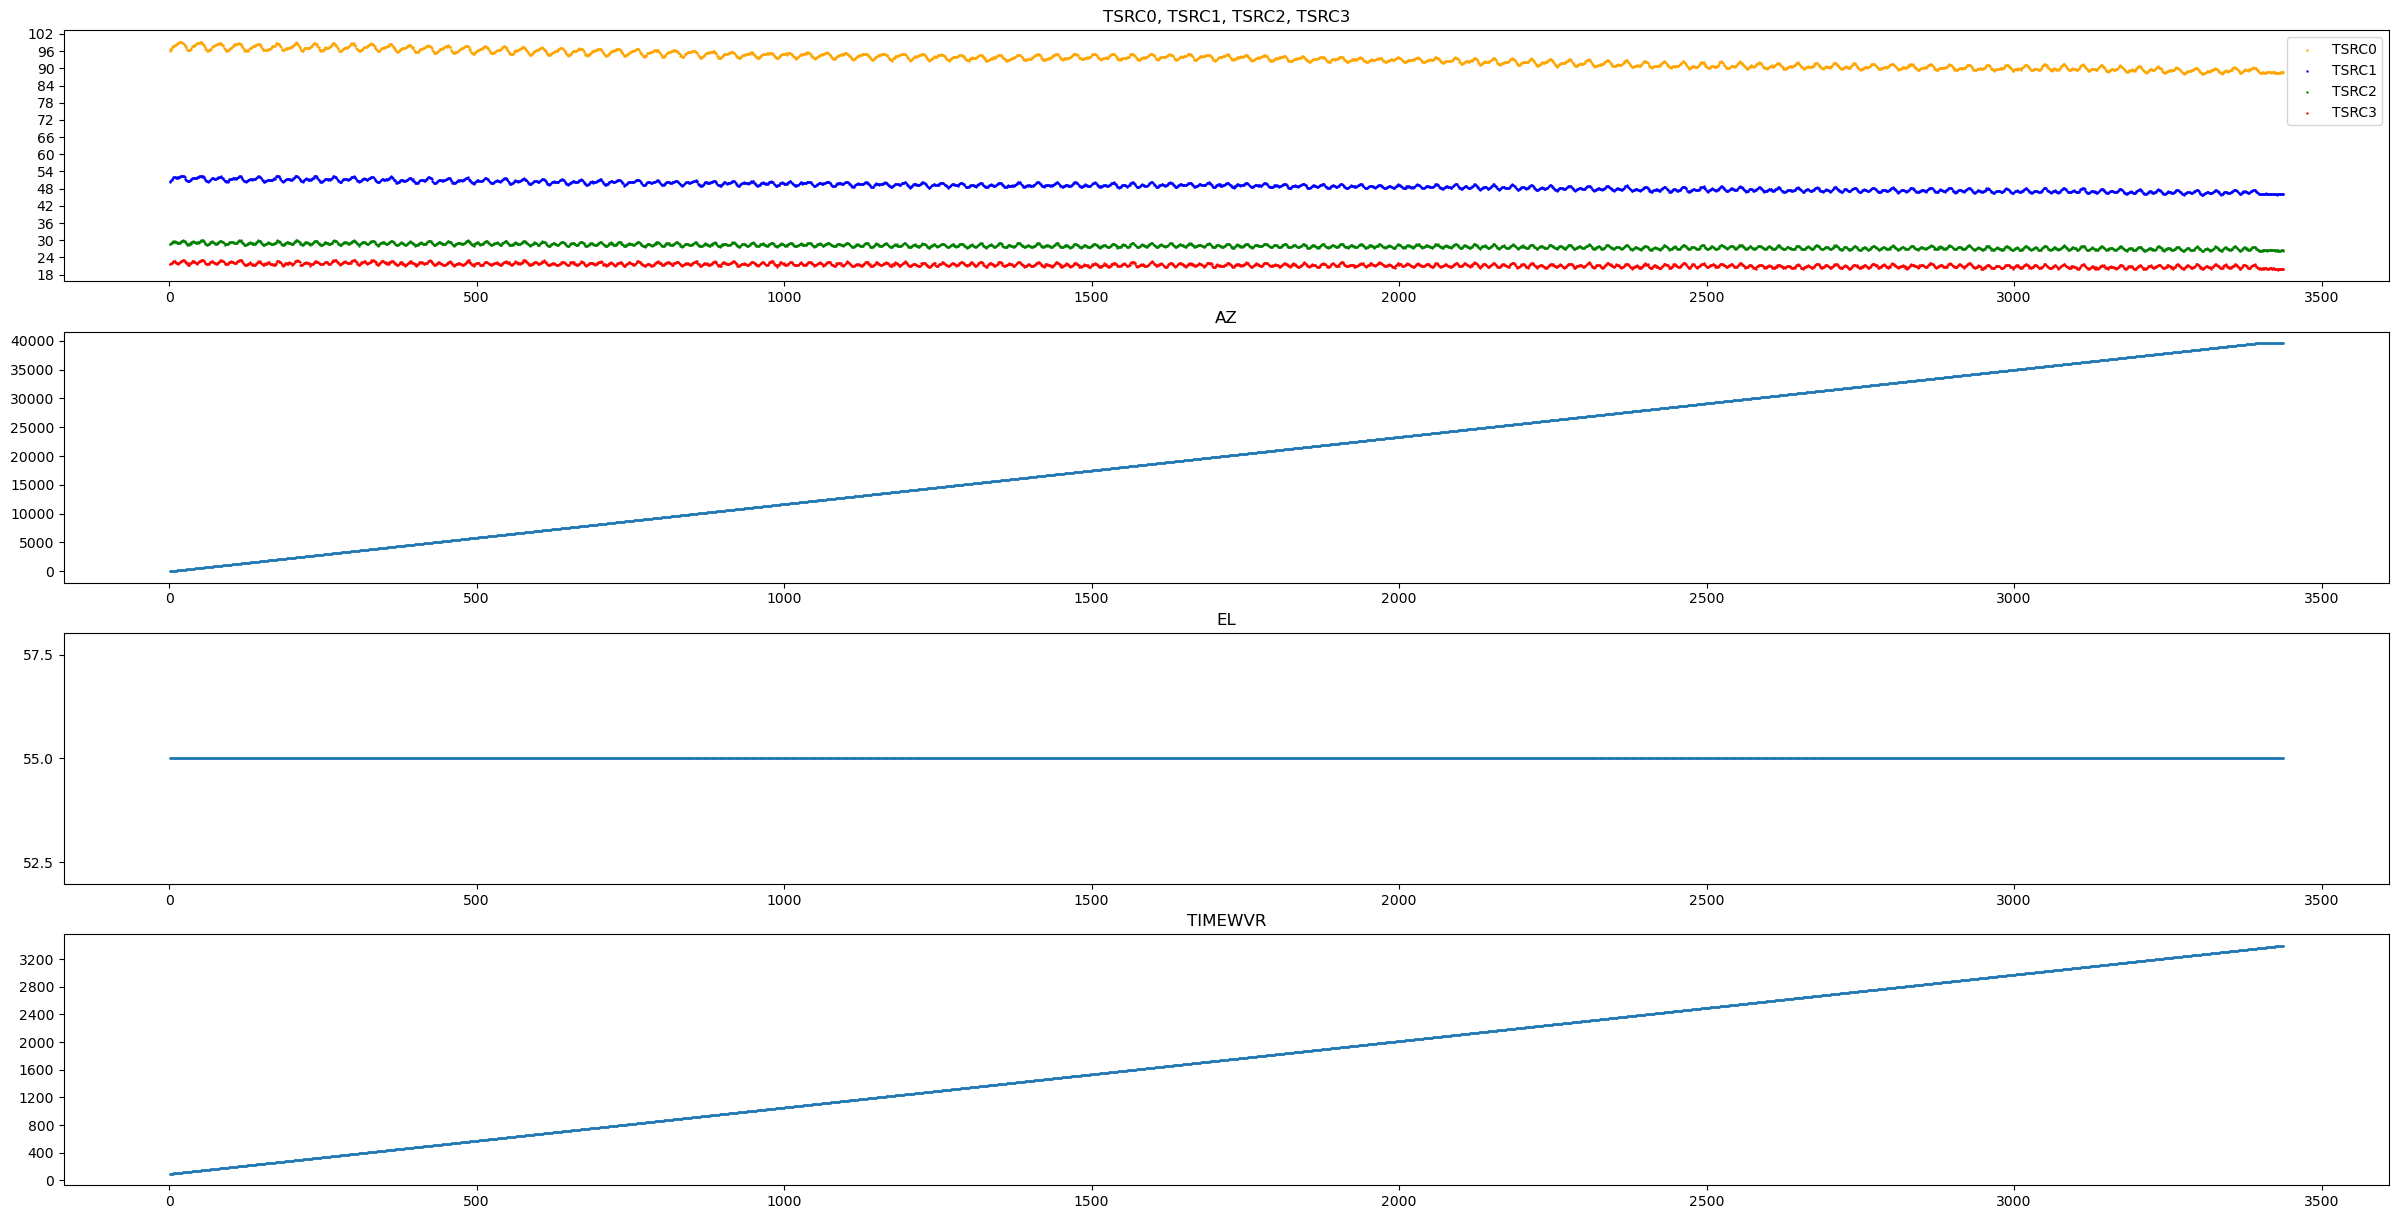

In [29]:
"""
Yifu

purpose: To read text files and plot the 
    4 combinations of data which including TSRC0 TSRC1 TSRC2 TSRC3 EL AZ
    Time? TIME/TIMEWVR
"""

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime
import glob 
from matplotlib.ticker import MaxNLocator


file_list = glob.glob("*.txt")

new_f = []


with open('20240724_110135_scanAz_slow.txt', 'r') as f:
    # Read the file line by line
    for line in f:
        if line.startswith('#'):
            continue
        split_rows = line.split()
        new_f.append(split_rows)

df = pd.DataFrame(new_f)

#plot
fig, axs = plt.subplots(figsize=(30, 15), nrows=4 )
#plt.figure(figsize=(10, 6))
# plt.plot(df.index, df[0], label='TIME')
# plt.title('TIME')
# plt.show()
# plt.close()
timewvr = df[1][1:].astype(float)

axs[3].scatter(df.index[1:], timewvr, label='TIMEWVR', s=0.5)
axs[3].set_title('TIMEWVR')
axs[3].yaxis.set_major_locator(MaxNLocator(nbins=10))

T0 = df[19][1:].astype(float)
T1 = df[20][1:].astype(float)
T2 = df[21][1:].astype(float)
T3 = df[22][1:].astype(float)

T0_25 = np.percentile(T0, 25)
T0_50 = np.percentile(T0, 50)
T0_75 = np.percentile(T0, 75)
T0_ave = np.mean(T0)
T0_std = np.std(T0)
T0_max = np.max(T0)
T0_min = np.min(T0)

# print(f"TSRC0 - 25th percentile: {T0_25}")
# print(f"TSRC0 - 50th percentile: {T0_50}")
# print(f"TSRC0 - 75th percentile: {T0_75}")
# print(f"TSRC0 - average: {T0_ave}")
# print(f"TSRC0 - std deviation: {T0_std}")
# print(f"TSRC0 - max: {T0_max}")
# print(f"TSRC0 - min: {T0_min}")

axs[0].scatter(df.index[1:], T0, label='TSRC0', color='orange', s=0.5)
axs[0].scatter(df.index[1:], T1, label='TSRC1', color='blue', s=0.5)
axs[0].scatter(df.index[1:], T2, label='TSRC2', color='green', s=0.5)
axs[0].scatter(df.index[1:], T3, label='TSRC3', color='red', s=0.5)
axs[0].set_title('TSRC0, TSRC1, TSRC2, TSRC3')
axs[0].yaxis.set_major_locator(MaxNLocator(nbins=15))
axs[0].legend()

El = df[23][1:].astype(float)

axs[2].scatter(df.index[1:], El, label='EL', s=0.5)
axs[2].set_title('EL')
axs[2].yaxis.set_major_locator(MaxNLocator(nbins=3))

AZ = df[24][1:].astype(float)

axs[1].scatter(df.index[1:], AZ, label='AZ', s=0.5)
axs[1].set_title('AZ')
axs[1].yaxis.set_major_locator(MaxNLocator(nbins=10))

plt.show()
fig.savefig('scanAz_slow.png', dpi=400)
plt.close()